# Netflix Data Analysis
Exploratory data analysis of Netflix movies and TV shows using Python, Pandas, visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("netflix1.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
df.shape

(8790, 10)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [7]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

---

## Question: How has Netflix content grown over time?

In [10]:
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

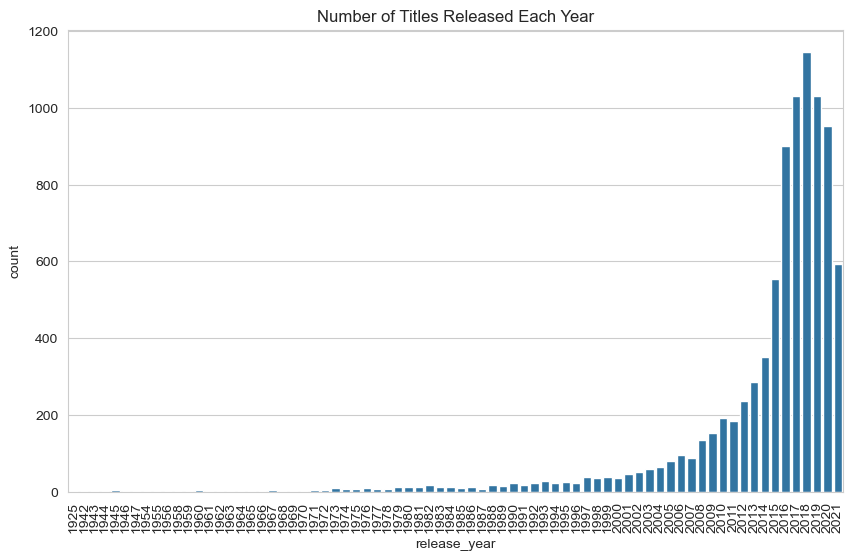

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(x="release_year", data=df, order=sorted(df["release_year"].unique()))
plt.xticks(rotation=90)
plt.title("Number of Titles Released Each Year")
plt.show()

### Insight: Netflix Content Growth
From this visualization, we can see that Netflix significantly increased content production starting around 2015. The platform experienced rapid growth between 2016-2019, peaking around 2018-2019. After 2019, the number of releases slightly declined.

This reflects Netflix's aggresive expansion into global streaming and original content production during that period.

---

## Question: Which countries produce the most Netflix content?

In [12]:
df["country"].value_counts().head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

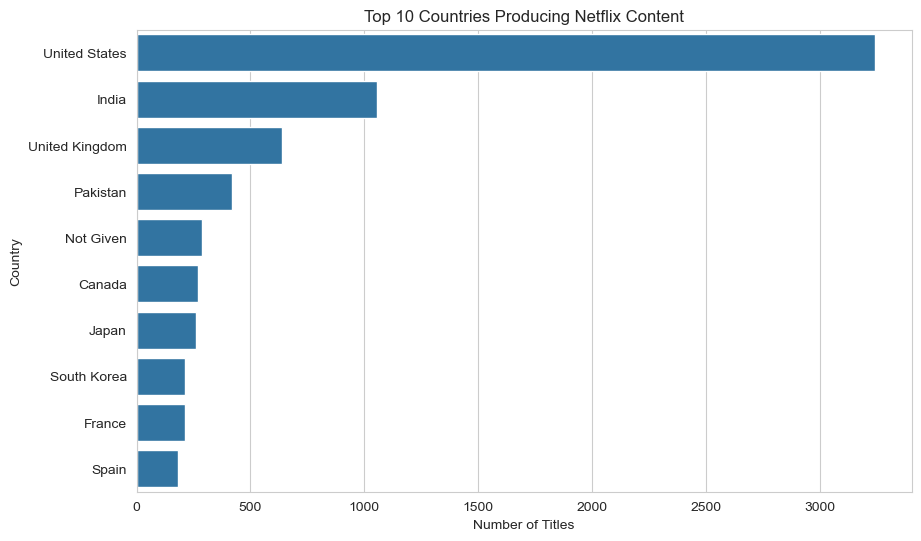

In [13]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Insight: Top Countries Producing Netflix Content 
From this visualization, we can see that the United States dominates Netflix content
production by a significant margin. It produces more than three times the number of titles
as the next highest country, India. Countries such as the United Kingdom, Pakistan, Canada, Japan, and South Korea also contribute meaningfully to the platform's catalog.

This highlights how Netflix relies heavily on U.S. content while simultaneously expanding
its global presence through increasing international production.

---

## Question: What ratings dominate Netflix?

In [14]:
df["rating"].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

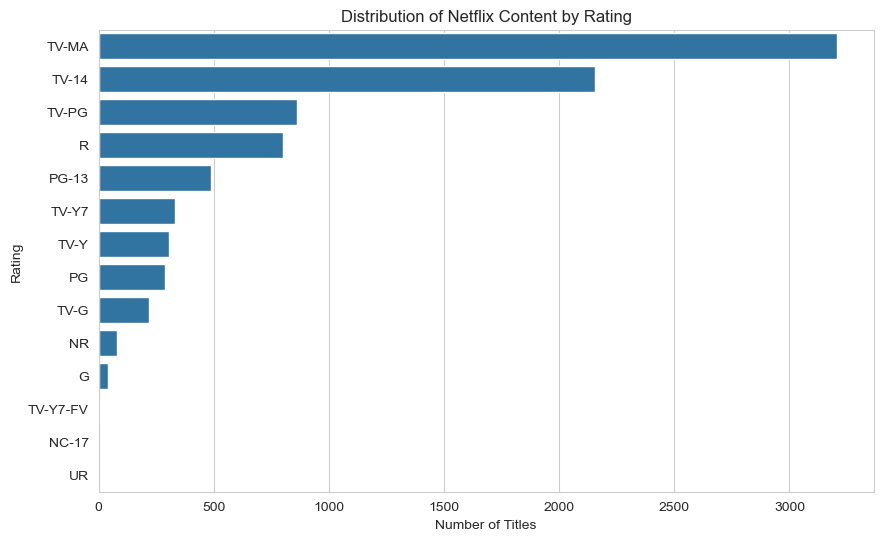

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(y="rating", data=df, order=df["rating"].value_counts().index)
plt.title("Distribution of Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

### Insight: Netflix Content Ratings
From this visualization, we can see that TV-MA and TV-14 dominate Netflix's catalog by a large
margin. This indicates that Netflix primarily targets mature and teen audiences rather than young children. Ratings for kids and family content (TV-Y, TV-G, PG) make up a much smaller portion of the platform.

This suggests Netflix focuses heavily on adult-oriented content.

---

## Question: What is the distribution of movie durations on Netflix?

In [16]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.replace(" min", "")
movies["duration_min"] = movies["duration_min"].astype(int)

movies["duration_min"].head()

0     90
3     91
4    125
6    104
7     87
Name: duration_min, dtype: int64

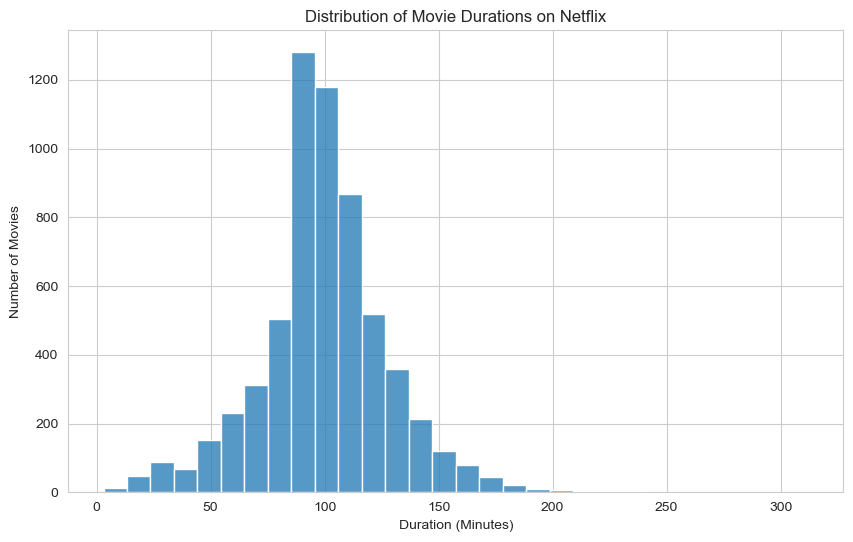

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(movies["duration_min"], bins=30)
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

### Insight: Movie Duration Distribution
From this visualization, we can see that most Netflix movies fall between 80 and 120 minutes in length. The distribution peaks around the 90-100 minute mark, indicating that Netflix favors standard feature-length films. Very short and very long movies are much less common.

This suggests Netflix prioritizes typical movie runtimes that align with viewer attention spans and industry norms.

---

## Question: What are the most popular Netflix genres?

In [18]:
genres = df.copy()

genres["listed_in"] = genres["listed_in"].str.split(", ")

genres_exploded = genres.explode("listed_in")

genres_exploded["listed_in"].value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

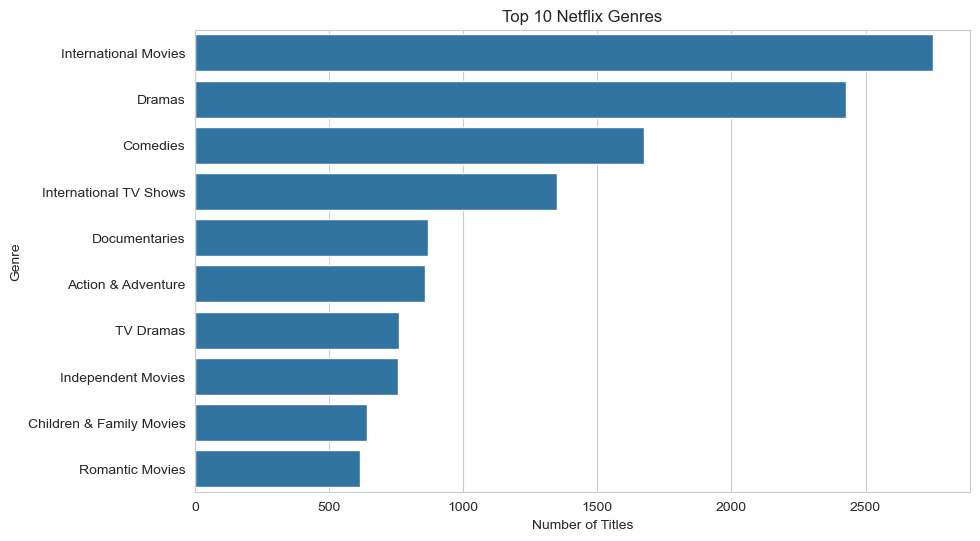

In [19]:
top_genres = genres_exploded["listed_in"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Insight: Most Popular Netflix Genres

From this visualization, we can see that International Movies and Dramas dominate Netflix’s catalog, followed by Comedies and International TV Shows. This shows that Netflix has a strong focus on global content and storytelling rather than relying only on domestic productions.

The prominence of documentaries, action & adventure, and family content also highlights Netflix’s strategy to appeal to a wide variety of audiences and viewing preferences.

---

## Question: How have Movies vs TV Shows changed over time?

In [20]:
year_type = df.groupby(["release_year", "type"]).size().reset_index(name="count")
year_type.head()

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


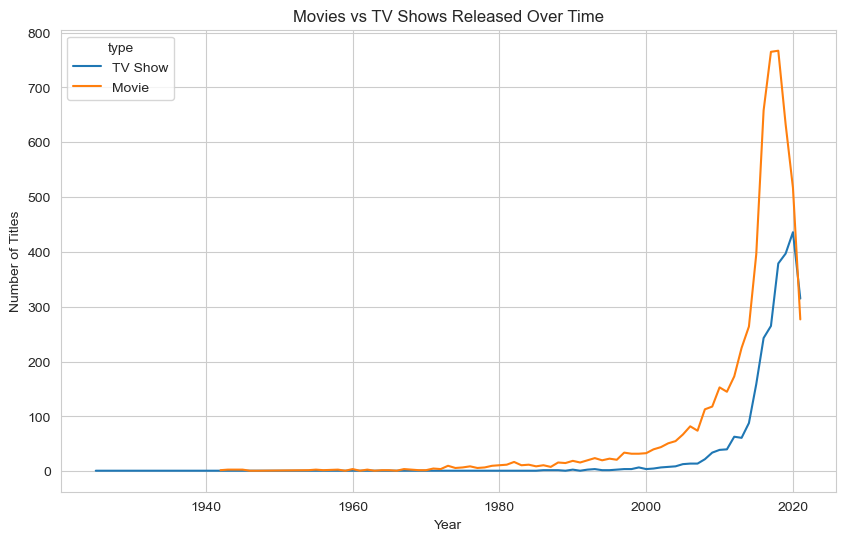

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(data=year_type, x="release_year", y="count", hue="type")
plt.title("Movies vs TV Shows Released Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Insight: Movies vs TV Shows Over Time

From this visualization, we can see that both movies and TV shows experienced massive growth after 2015. Movies initially dominated Netflix’s catalog, but TV shows began growing rapidly in the late 2010s.

This reflects Netflix’s shift toward binge-watchable series and original TV content as streaming became more popular.

---

## Question: Can I build a simple content-based recommendation system?

In [22]:
rec_df = df.copy()

rec_df["content_features"] = rec_df["listed_in"] + " " + rec_df["rating"]

rec_df[["title", "content_features"]].head()

,title,content_features
0,Dick Johnson Is Dead,Documentaries PG-13
1,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
2,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries TV-MA"
3,Confessions of an Invisible Girl,"Children & Family Movies, Comedies TV-PG"
4,Sankofa,"Dramas, Independent Movies, International Movi..."


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(rec_df["content_features"])

tfidf_matrix.shape

(8790, 54)

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape

(8790, 8790)

In [25]:
def recommend(title, cosine_sim=cosine_sim):
    idx = rec_df[rec_df["title"] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return rec_df["title"].iloc[movie_indices]

In [26]:
recommend("Sankofa")

280    LSD: Love, Sex Aur Dhokha
382         La diosa del asfalto
559              African America
775                Into the Wind
805                     Fan Girl
Name: title, dtype: object

In [27]:
recommend("Stranger Things")

7633        Stranger Things
7446            Nightflyers
8485                  Helix
6613               Manifest
8122    The Vampire Diaries
Name: title, dtype: object

### Insight: Simple Recommendation System

I built a basic content-based recommendation system using genre and rating information. By converting text features into numerical vectors and computing cosine similarity, I can identify titles that are most similar to a selected movie or TV show.

This demonstrates how machine learning techniques can be used to power recommendation engines similar to those used by streaming platforms.

---

## Final Insights & Conclusions

This analysis explored trends in Netflix content using exploratory data analysis and a simple recommendation system.

### Key Findings

• Netflix has dramatically increased content production since 2015, with rapid growth between 2016–2019.  
• Movies make up the majority of Netflix's catalog, though TV Shows have grown significantly in recent years.  
• The United States dominates content production, followed by India and the United Kingdom.  
• TV-MA and TV-14 ratings are the most common, showing a strong focus on mature audiences.  
• Most Netflix movies fall between 80–120 minutes in length.  
• International Movies and Dramas are the most common genres on the platform.  

### Machine Learning Component

A simple content-based recommendation system was built using TF-IDF and cosine similarity to suggest similar titles based on genres and ratings.

This project demonstrates skills in:
• Data cleaning  
• Data visualization  
• Exploratory data analysis  
• Feature engineering  
• Introductory machine learning  
• Building an end-to-end data project